# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (f1_score, accuracy_score,
                             precision_score, recall_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

# Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Data

In [3]:
path = '/content/drive/MyDrive/DSPL'

train = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-train.csv')
validation = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-validation.csv')
test = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-test.csv')

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (27499, 24)
Validation shape: (2749, 24)
Test shape: (4318, 23)


# Feature Engineering

In [4]:
for df in [train, validation, test]:
    df['Booking_date'] = pd.to_datetime(df['Booking_date'])
    df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
    df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])

    for col in ['Adults', 'Children', 'Babies',
                'Room_Rate', 'Previous_Cancellations',
                'Income', 'Discount_Rate']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days
    df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

    df['high_risk_flag'] = ((df['Lead_Time'] > 100) &
                            (df['Deposit_type'] == 'No Deposit')).astype(int)
    df['family_size'] = df['Adults'] + df['Children'] + df['Babies']
    df['revenue_risk'] = df['Room_Rate'] * df['Lead_Time']

    df['booking_month'] = df['Booking_date'].dt.month
    df['checkin_month'] = df['Expected_checkin'].dt.month
    df['is_peak_season'] = df['checkin_month'].isin([6,7,8,12]).astype(int)
    df['checkin_dayofweek'] = df['Expected_checkin'].dt.dayofweek
    df['is_weekend'] = df['checkin_dayofweek'].isin([5,6]).astype(int)

print(train.shape)

(27499, 34)


# Data Cleaning

In [5]:
status_mapping = {
    'Check-out': 'Check-Out',
    'Check-in': 'Check-Out',
    'Check-In': 'Check-Out',
    'Checkin': 'Check-Out',
    'CheckIn': 'Check-Out'
}

for df in [train, validation]:
    df['Reservation_Status'] = df['Reservation_Status'].replace(status_mapping)

valid_statuses = ['Check-Out', 'Canceled', 'No-Show']
train = train[train['Reservation_Status'].isin(valid_statuses)]
validation = validation[validation['Reservation_Status'].isin(valid_statuses)]

train = train[train['Lead_Time'] >= 0]
train = train[train['Length_of_Stay'] > 0]
train = train.dropna(subset=['Deposit_type', 'Visted_Previously', 'Room_Rate'])

validation = validation[validation['Lead_Time'] >= 0]
validation = validation[validation['Length_of_Stay'] > 0]
validation = validation.dropna(subset=['Deposit_type', 'Visted_Previously', 'Room_Rate'])

print(train.shape, validation.shape)
print(train['Reservation_Status'].value_counts())

(26993, 34) (2733, 34)
Reservation_Status
Check-Out    20777
Canceled      4108
No-Show       2108
Name: count, dtype: int64


# Drop columns not needed for modelling

In [6]:
drop_cols = ['Reservation-id', 'Booking_date',
             'Expected_checkin', 'Expected_checkout']

train = train.drop(columns=drop_cols, errors='ignore')
validation = validation.drop(columns=drop_cols, errors='ignore')
test = test.drop(columns=drop_cols, errors='ignore')

print("Remaining columns:", list(train.columns))

Remaining columns: ['Gender', 'Age', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region', 'Hotel_Type', 'Adults', 'Children', 'Babies', 'Meal_Type', 'Visted_Previously', 'Previous_Cancellations', 'Deposit_type', 'Booking_channel', 'Required_Car_Parking', 'Reservation_Status', 'Use_Promotion', 'Discount_Rate', 'Room_Rate', 'Lead_Time', 'Length_of_Stay', 'high_risk_flag', 'family_size', 'revenue_risk', 'booking_month', 'checkin_month', 'is_peak_season', 'checkin_dayofweek', 'is_weekend']


# Split features and target variable

In [7]:
y_train = train['Reservation_Status']
y_val = validation['Reservation_Status']

X_train = train.drop(columns=['Reservation_Status'])
X_val = validation.drop(columns=['Reservation_Status'])

print(X_train.shape, X_val.shape)
print(y_train.value_counts())

(26993, 29) (2733, 29)
Reservation_Status
Check-Out    20777
Canceled      4108
No-Show       2108
Name: count, dtype: int64


# Label Encoding

In [8]:
le = LabelEncoder()

status_mapping = {
    'Check-out': 'Check-Out',
    'Check-in': 'Check-Out',
    'Check-In': 'Check-Out',
    'Checkin': 'Check-Out',
    'CheckIn': 'Check-Out'
}

train['Reservation_Status'] = train['Reservation_Status'].replace(status_mapping)
validation['Reservation_Status'] = validation['Reservation_Status'].replace(status_mapping)

valid_statuses = ['Check-Out', 'Canceled', 'No-Show']
train = train[train['Reservation_Status'].isin(valid_statuses)]
validation = validation[validation['Reservation_Status'].isin(valid_statuses)]

y_train = train['Reservation_Status']
y_val = validation['Reservation_Status']
X_train = train.drop(columns=['Reservation_Status'])
X_val = validation.drop(columns=['Reservation_Status'])

all_X = pd.concat([X_train, X_val, test], ignore_index=True)
cat_cols = X_train.select_dtypes(include='object').columns

for col in cat_cols:
    le_feat = LabelEncoder()
    le_feat.fit(all_X[col].astype(str))
    X_train[col] = le_feat.transform(X_train[col].astype(str))
    X_val[col] = le_feat.transform(X_val[col].astype(str))
    test[col] = le_feat.transform(test[col].astype(str))

le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)

print(le.classes_)

['Canceled' 'Check-Out' 'No-Show']


# Class Balancing using SMOTETomek

In [9]:
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train_enc)

print(pd.Series(y_train_res).value_counts())

2    20071
0    20015
1    19619
Name: count, dtype: int64


# Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)

# Model Evaluation

In [11]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)

    try:
        y_prob = model.predict_proba(X_v)
        roc = roc_auc_score(y_v, y_prob,
                            multi_class='ovr',
                            average='macro')
    except:
        roc = 0.0

    acc = accuracy_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred,
                           average='macro',
                           zero_division=0)
    rec = recall_score(y_v, y_pred,
                       average='macro',
                       zero_division=0)
    f1 = f1_score(y_v, y_pred,
                  average='macro',
                  zero_division=0)

    results.append([name,
                    round(acc, 6),
                    round(prec, 6),
                    round(rec, 6),
                    round(f1, 6),
                    round(roc, 6)])

    print(f"{name}: F1={round(f1,3)}, Acc={round(acc,3)}")
    return model

# Model Training

In [12]:
# Logistic Regression
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
evaluate_model("Logistic Regression", lr,
               X_train_scaled, y_train_res,
               X_val_scaled, y_val_enc)

# Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
evaluate_model("Decision Tree", dt,
               X_train_res, y_train_res,
               X_val, y_val_enc)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model("Random Forest", rf,
               X_train_res, y_train_res,
               X_val, y_val_enc)

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)
evaluate_model("XGBoost", xgb,
               X_train_res, y_train_res,
               X_val, y_val_enc)

# ANN
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True
)
evaluate_model("ANN", ann,
               X_train_scaled, y_train_res,
               X_val_scaled, y_val_enc)

Logistic Regression: F1=0.302, Acc=0.518
Decision Tree: F1=0.348, Acc=0.453
Random Forest: F1=0.31, Acc=0.543
XGBoost: F1=0.305, Acc=0.547
ANN: F1=0.315, Acc=0.517


MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              max_iter=500, random_state=42)

# Model Comparison

In [13]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision",
             "Recall", "F1 Score", "ROC-AUC"]
)

print("MODEL COMPARISON")
print(results_df.to_string())
print()

best_row = results_df.loc[results_df["F1 Score"].idxmax()]
best_model_name = best_row["Model"]
print("Best Model:", best_model_name)
print("Best Macro F1:", round(best_row["F1 Score"], 3))

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.517746   0.325228  0.329432  0.302445  0.490619
1        Decision Tree  0.453348   0.356158  0.353385  0.347861  0.519416
2        Random Forest  0.542993   0.342175  0.339303  0.309761  0.510724
3              XGBoost  0.547384   0.346102  0.340038  0.305497  0.502307
4                  ANN  0.516648   0.332741  0.334592  0.315458  0.503527

Best Model: Decision Tree
Best Macro F1: 0.348


# Model Comparison Chart

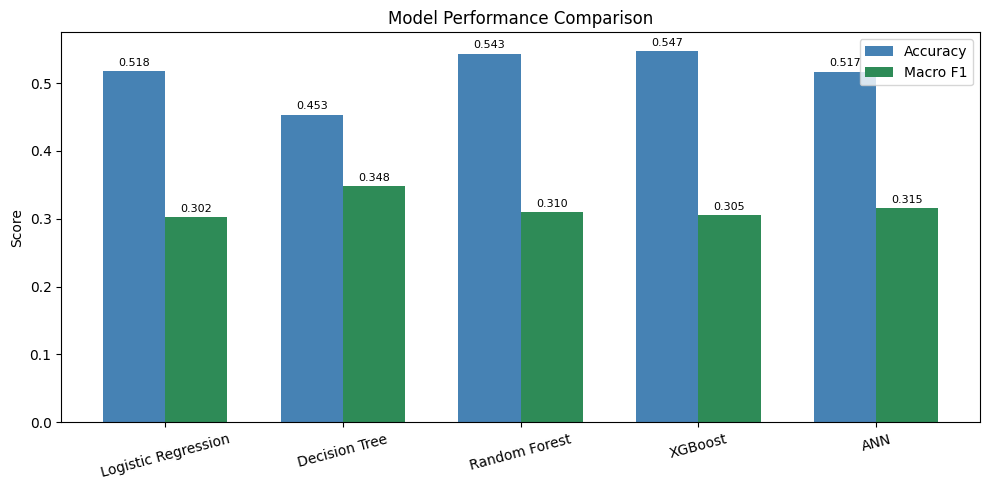

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['F1 Score'], width, label='Macro F1', color='seagreen')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.show()

# Final Model Training

In [17]:
if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42)
    final_model.fit(X_train_scaled, y_train_res)
    X_test_final = scaler.transform(test)

elif best_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42)
    final_model.fit(X_train_res, y_train_res)
    X_test_final = test

elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1)
    final_model.fit(X_train_res, y_train_res)
    X_test_final = test

elif best_model_name == "XGBoost":
    final_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss')
    final_model.fit(X_train_res, y_train_res)
    X_test_final = test

elif best_model_name == "ANN":
    final_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42,
        early_stopping=True)
    final_model.fit(X_train_scaled, y_train_res)
    X_test_final = scaler.transform(test)

print("Final model:", best_model_name)

Final model: Decision Tree


# Test Set Predictions

In [18]:
test_pred = final_model.predict(X_test_final)
test_pred_labels = le.inverse_transform(test_pred)

pred_counts = pd.Series(test_pred_labels).value_counts()
print(pred_counts)

total = len(test_pred_labels)
canceled = pred_counts.get('Canceled', 0)
noshow = pred_counts.get('No-Show', 0)
total_risk = canceled + noshow
print(f"High risk: {total_risk:,} ({total_risk/total*100:.2f}%)")

Check-Out    2724
No-Show       921
Canceled      673
Name: count, dtype: int64
High risk: 1,594 (36.92%)


# Confusion Matrix

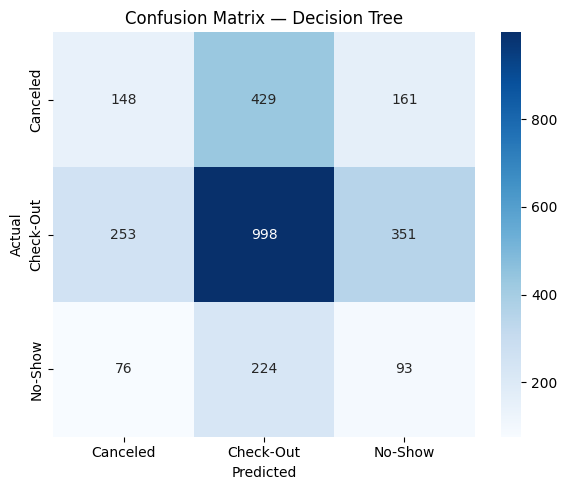

              precision    recall  f1-score   support

    Canceled       0.31      0.20      0.24       738
   Check-Out       0.60      0.62      0.61      1602
     No-Show       0.15      0.24      0.19       393

    accuracy                           0.45      2733
   macro avg       0.36      0.35      0.35      2733
weighted avg       0.46      0.45      0.45      2733



In [19]:
if best_model_name in ["Logistic Regression", "ANN"]:
    y_pred_cm = final_model.predict(X_val_scaled)
else:
    y_pred_cm = final_model.predict(X_val)

cm = confusion_matrix(y_val_enc, y_pred_cm)
labels = le.classes_

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_val_enc, y_pred_cm, target_names=labels))

# Feature Importance

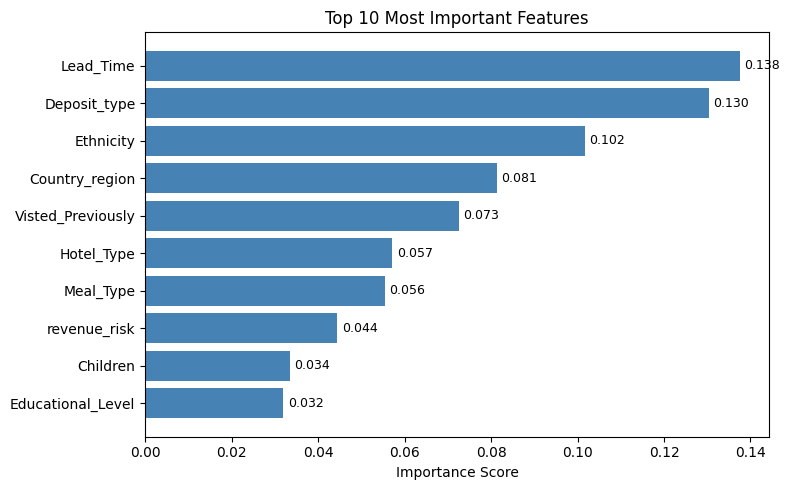

Lead_Time            0.137516
Deposit_type         0.130339
Ethnicity            0.101777
Country_region       0.081417
Visted_Previously    0.072508
Hotel_Type           0.057193
Meal_Type            0.055506
revenue_risk         0.044466
Children             0.033502
Educational_Level    0.031978
dtype: float64


In [22]:
if best_model_name in ["Decision Tree", "Random Forest", "XGBoost"]:
    importances = pd.Series(
        final_model.feature_importances_,
        index=X_train.columns)
    top10 = importances.sort_values(ascending=True).tail(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(top10.index, top10.values, color='steelblue')
    for bar, val in zip(bars, top10.values):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title('Top 10 Most Important Features')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print(importances.sort_values(ascending=False).head(10))

# Prediction Distribution

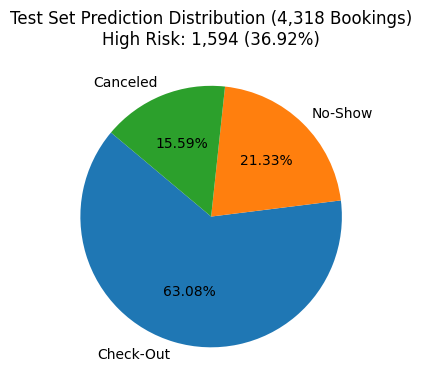

In [24]:
pred_counts = pd.Series(test_pred_labels).value_counts()
total = len(test_pred_labels)

canceled = pred_counts.get('Canceled', 0)
noshow = pred_counts.get('No-Show', 0)
total_risk = canceled + noshow
risk_pct = total_risk/total*100

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(
    pred_counts.values,
    labels=pred_counts.index,
    autopct='%1.2f%%',
    startangle=140)

ax.set_title(f'Test Set Prediction Distribution ({total:,} Bookings)\nHigh Risk: {total_risk:,} ({risk_pct:.2f}%)')
plt.tight_layout()
plt.show()

# Revenue Analysis

In [25]:
train_orig = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-train.csv')
train_orig['Reservation_Status'] = train_orig['Reservation_Status'].replace({'Check-out': 'Check-Out'})
train_orig['Expected_checkin'] = pd.to_datetime(train_orig['Expected_checkin'])
train_orig['Expected_checkout'] = pd.to_datetime(train_orig['Expected_checkout'])
train_orig['Booking_date'] = pd.to_datetime(train_orig['Booking_date'])
train_orig['Lead_Time'] = (train_orig['Expected_checkin'] - train_orig['Booking_date']).dt.days
train_orig['Length_of_Stay'] = (train_orig['Expected_checkout'] - train_orig['Expected_checkin']).dt.days
train_orig = train_orig[train_orig['Lead_Time'] >= 0]
train_orig = train_orig[train_orig['Length_of_Stay'] > 0]
train_orig = train_orig.dropna(subset=['Room_Rate'])
train_orig['Revenue'] = train_orig['Room_Rate'] * train_orig['Length_of_Stay']

lost = train_orig[train_orig['Reservation_Status'] != 'Check-Out']['Revenue'].sum()
total_rev = train_orig['Revenue'].sum()
total_cancel = len(train_orig[train_orig['Reservation_Status'] != 'Check-Out'])

print(f"Total revenue: £{total_rev:,.0f}")
print(f"Revenue lost: £{lost:,.0f} ({lost/total_rev*100:.1f}%)")
print(f"Average per cancellation: £{lost/total_cancel:,.0f}")

Total revenue: £8,632,858
Revenue lost: £1,985,459 (23.0%)
Average per cancellation: £319


# Recommendation Data Verification

In [26]:
# Lead time analysis
high_lead = train_orig[train_orig['Lead_Time'] > 100]
high_cancel = high_lead[high_lead['Reservation_Status'] != 'Check-Out']
print(f"Bookings >100 days: {len(high_lead):,} — cancel rate: {len(high_cancel)/len(high_lead)*100:.1f}%")

# No deposit analysis
no_dep = train_orig[train_orig['Deposit_type'] == 'No Deposit']
no_dep_cancel = no_dep[no_dep['Reservation_Status'] != 'Check-Out']
print(f"No deposit bookings: {len(no_dep):,} — cancel rate: {len(no_dep_cancel)/len(no_dep)*100:.1f}%")

# Visited previously
first = train_orig[train_orig['Visted_Previously'] == 'No']
first_cancel = first[first['Reservation_Status'] != 'Check-Out']
ret = train_orig[train_orig['Visted_Previously'] == 'Yes']
ret_cancel = ret[ret['Reservation_Status'] != 'Check-Out']
print(f"First-time guests: {len(first):,} — cancel rate: {len(first_cancel)/len(first)*100:.1f}%")
print(f"Returning guests: {len(ret):,} — cancel rate: {len(ret_cancel)/len(ret)*100:.1f}%")

print(f"\nRevenue lost: £{lost:,.0f} ({lost/total_rev*100:.1f}% of £{total_rev:,.0f})")

Bookings >100 days: 13,838 — cancel rate: 24.5%
No deposit bookings: 17,891 — cancel rate: 23.4%
First-time guests: 18,001 — cancel rate: 23.2%
Returning guests: 8,992 — cancel rate: 22.6%

Revenue lost: £1,985,459 (23.0% of £8,632,858)
